<a href="https://colab.research.google.com/github/Wertiba/Wertiba/blob/main/optimized_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# НТО ИИ 2025-2026: Командный этап (Baseline)

Единый ноутбук с полным циклом решения командной задачи: от загрузки данных до формирования файла с ответами.

### Структура решения:
1. **Конфигурация**: Настройка путей и параметров.
2. **Утилиты**: Вспомогательные функции.
3. **Загрузка данных**: Чтение и объединение таблиц.
4. **Генерация признаков**: Создание фичей для обучения (текстовые, агрегации).
5. **Валидация**: Стратегия проверки качества (Temporal Split) и метрики.
6. **Обучение**: Тренировка модели LightGBM.
7. **Предсказание**: Генерация сабмита для тестовой выборки.
8. **Проверка**: Техническая валидация файла ответов.

In [1]:
ls -al

total 28
drwxr-xr-x 1 root root 4096 Dec  7 20:08 ./
drwxr-xr-x 1 root root 4096 Dec  7 20:03 ../
drwxr-xr-x 4 root root 4096 Nov 20 14:30 .config/
drwxr-xr-x 5 root root 4096 Dec  7 20:07 data/
drwxr-xr-x 2 root root 4096 Dec  7 20:06 .ipynb_checkpoints/
drwxr-xr-x 4 root root 4096 Dec  7 20:08 output/
drwxr-xr-x 1 root root 4096 Nov 20 14:30 sample_data/


In [2]:
# !pip install pyarrow

In [3]:
# import pandas as pd
# import os

# os.makedirs("data/processed", exist_ok=True)

# df = pd.DataFrame({
#     "source": ["train", "train", "test"],
#     "user_id": [1, 2, 3],
#     "candidate_id": [10, 20, 30],
#     "label": [1, 0, None],
#     "feature_1": [0.1, 0.2, 0.3],
#     "feature_2": [5, 10, 15],
# })

# df.to_parquet("data/processed/processed_features.parquet", engine="pyarrow")
# print("DONE")


In [4]:
# === ИМПОРТ БИБЛИОТЕК ===
import pandas as pd
import numpy as np
import lightgbm as lgb
import gc
import json
import warnings
import time
import sys
import os
import argparse
from pathlib import Path
from typing import Any, List, Dict, Tuple, Set, Union
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, precision_score, recall_score
import joblib
from tqdm import tqdm
try:
    import torch
    from transformers import AutoModel, AutoTokenizer
except ImportError:
    torch = None
    print("Warning: torch or transformers not installed. BERT features will be disabled if requested.")

# Настройки
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)



## 1. Конфигурация и Константы
Здесь определены пути к файлам, названия колонок и гиперпараметры модели.

In [5]:
class constants:
    # --- FILENAMES ---
    TRAIN_FILENAME = "train.csv"
    TARGETS_FILENAME = "targets.csv"
    CANDIDATES_FILENAME = "candidates.csv"
    USER_DATA_FILENAME = "users.csv"
    BOOK_DATA_FILENAME = "books.csv"
    BOOK_GENRES_FILENAME = "book_genres.csv"
    GENRES_FILENAME = "genres.csv"
    BOOK_DESCRIPTIONS_FILENAME = "book_descriptions.csv"
    SUBMISSION_FILENAME = "submission.csv"
    PROCESSED_DATA_FILENAME = "processed_features.parquet"
    MODEL_FILENAME = "lgb_model.txt"
    TFIDF_VECTORIZER_FILENAME = "tfidf_vectorizer.pkl"
    BERT_EMBEDDINGS_FILENAME = "bert_embeddings.pkl"

    # --- COLUMN NAMES ---
    COL_USER_ID = "user_id"
    COL_BOOK_ID = "book_id"
    COL_RATINGS = "rating"
    COL_SOURCE = "source"  # train или test
    COL_TIMESTAMP = "timestamp"
    COL_TARGET = "target"
    COL_PREDICTION = "prediction"
    COL_BOOK_ID_LIST = "book_id_list"

    # Metadata columns
    COL_TITLE = "title"
    COL_AUTHOR = "author"
    COL_PUBLISHER = "publisher"
    COL_PUBLICATION_YEAR = "publication_year"
    COL_IMAGE_URL = "image_url"
    COL_GENDER = "gender"
    COL_AGE = "age"
    COL_AGE_GROUP = "age_group"
    COL_HAS_READ = "has_read"
    COL_DESCRIPTION = "description"
    COL_GENRES = "genres"
    COL_AUTHOR_ID = "author_id"
    COL_LANGUAGE = "language"
    COL_AVG_RATING = "avg_rating"
    COL_RELEVANCE = "relevance"  # New target for multiclass: 0=cold, 1=planned, 2=read
    COL_GENRE_ID = "genre_id"

    # Feature columns
    F_USER_MEAN_RATING = "user_mean_rating"
    F_USER_RATINGS_COUNT = "user_ratings_count"
    F_BOOK_MEAN_RATING = "book_mean_rating"
    F_BOOK_RATINGS_COUNT = "book_ratings_count"
    F_AUTHOR_MEAN_RATING = "author_mean_rating"
    F_BOOK_GENRES_COUNT = "book_genres_count"
    F_USER_BOOK_INTERACTION = "f_user_book_interaction"

    # --- VALUES ---
    VAL_SOURCE_TRAIN = "train"
    VAL_SOURCE_TEST = "test"

    # --- MAGIC NUMBERS ---
    MAX_RANKING_LENGTH = 20
    MISSING_CAT_VALUE = "-1"
    MISSING_NUM_VALUE = -1


In [6]:
class config:
    # --- DIRECTORIES ---
    # Пути к данным (предполагаем, что папка data лежит рядом с ноутбуком)
    ROOT_DIR = Path(".")
    DATA_DIR = ROOT_DIR / "data"
    RAW_DATA_DIR = DATA_DIR / "raw"
    PROCESSED_DATA_DIR = DATA_DIR / "processed"
    MODEL_DIR = Path("output/models")
    SUBMISSION_DIR = Path("output/submissions")
    MODEL_FILENAME = 'model.json'

    # Создаем папки, если их нет
    PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    SUBMISSION_DIR.mkdir(parents=True, exist_ok=True)

    # --- PARAMETERS ---
    RANDOM_STATE = 42
    TARGET = constants.COL_RELEVANCE

    # --- TEMPORAL SPLIT CONFIG ---
    TEMPORAL_SPLIT_RATIO = 0.8

    # --- TRAINING CONFIG ---
    EARLY_STOPPING_ROUNDS = 50

    # --- TF-IDF PARAMETERS ---
    TFIDF_MAX_FEATURES = 500
    TFIDF_MIN_DF = 2
    TFIDF_MAX_DF = 0.95
    TFIDF_NGRAM_RANGE = (1, 2)

    # --- BERT PARAMETERS ---
    BERT_MODEL_NAME = "DeepPavlov/rubert-base-cased"
    BERT_BATCH_SIZE = 8
    BERT_MAX_LENGTH = 512
    BERT_EMBEDDING_DIM = 768
    BERT_DEVICE = "cuda" if torch and torch.cuda.is_available() else "cpu"
    BERT_GPU_MEMORY_FRACTION = 0.75

    # --- FEATURES ---
    CAT_FEATURES = [
        constants.COL_USER_ID,
        constants.COL_BOOK_ID,
        constants.COL_GENDER,
        constants.COL_AGE,
        constants.COL_AUTHOR_ID,
        constants.COL_PUBLICATION_YEAR,
        constants.COL_LANGUAGE,
        constants.COL_PUBLISHER,
    ]

    # --- MODEL PARAMETERS ---
    LGB_PARAMS = {
        "objective": "multiclass",
        "num_class": 3,
        "metric": "multi_logloss",
        "n_estimators": 2000,
        "learning_rate": 0.01,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 1,
        "lambda_l1": 0.1,
        "lambda_l2": 0.1,
        "num_leaves": 31,
        "verbose": -1,
        "n_jobs": -1,
        "seed": RANDOM_STATE,
        "boosting_type": "gbdt",
        "max_bin": 255,
        "force_row_wise": True,
    }

    LGB_FIT_PARAMS = {
        "eval_metric": "multi_logloss",
        "callbacks": [],
    }


## 2. Вспомогательные утилиты (Utils)
Функции для воспроизводимости и оптимизации памяти.

In [7]:

def seed_everything(seed=42):
    import random as _random
    np.random.seed(seed)
    _random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    # Torch may be unavailable in this environment; guard calls accordingly.
    if 'torch' in globals() and torch is not None:
        try:
            torch.manual_seed(seed)
            try:
                if hasattr(torch, 'cuda') and torch.cuda.is_available():
                    torch.cuda.manual_seed_all(seed)
            except Exception:
                pass
            if hasattr(torch, 'backends') and hasattr(torch.backends, 'cudnn'):
                torch.backends.cudnn.deterministic = True
                torch.backends.cudnn.benchmark = False
        except Exception:
            # if torch exists but some attribute is missing, ignore to keep notebook runnable
            pass

seed_everything(config.RANDOM_STATE)


def reduce_mem_usage(df, verbose=True):
    start_mem = df.memory_usage().sum() / 1024**2

    for col in df.columns:
        col_type = df[col].dtype

        # Skip non-numeric columns
        if col_type == object or str(col_type) == "string":
            continue

        # Boolean to int8
        if col_type == bool:
            df[col] = df[col].astype("int8")
            continue

        # Numeric columns
        if pd.api.types.is_integer_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()

            if c_min >= -128 and c_max <= 127:
                df[col] = df[col].astype("int8")
            elif c_min >= -32768 and c_max <= 32767:
                df[col] = df[col].astype("int16")
            elif c_min >= -2147483648 and c_max <= 2147483647:
                df[col] = df[col].astype("int32")
            else:
                df[col] = df[col].astype("int64")

        elif pd.api.types.is_float_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()

            # Only compare floats to floats
            if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df[col] = df[col].astype("float32")
            else:
                df[col] = df[col].astype("float64")

    end_mem = df.memory_usage().sum() / 1024**2

    if verbose:
        print(f"Memory usage reduced: {start_mem:.2f} → {end_mem:.2f} MB "
              f"({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)")

    return df



In [8]:
## 2.1. EDA (Новый подраздел для анализа данных)
def perform_eda(train_df, book_genres_df, descriptions_df, user_data_df, book_data_df):
    print("Starting EDA...")

    # 1. Распределение целевой переменной (relevance)
    print("Relevance distribution:")
    print(train_df[constants.COL_RELEVANCE].value_counts(normalize=True))
    # Вывод: ожидается ~58% class 2 (read), ~42% class 1 (planned), 0% class 0 в train (cold в candidates).

    # 2. Временные паттерны
    train_df['day_of_week'] = train_df[constants.COL_TIMESTAMP].dt.dayofweek
    train_df['month'] = train_df[constants.COL_TIMESTAMP].dt.month
    print("Relevance by day of week:")
    print(train_df.groupby('day_of_week')[constants.COL_RELEVANCE].mean())
    # Insight: Возможно, чтение чаще в выходные -> добавить фичи.

    # 3. Пользовательские статистики
    user_stats = train_df.groupby(constants.COL_USER_ID).agg({
        constants.COL_RELEVANCE: ['count', 'mean'],
        constants.COL_BOOK_ID: 'nunique'
    }).reset_index()
    user_stats.columns = [constants.COL_USER_ID, 'user_interactions', 'user_mean_relevance', 'user_unique_books']
    print("User stats summary:")
    print(user_stats.describe())
    # Insight: Активные пользователи имеют выше mean_relevance -> добавить фичи на user activity.

    # 4. Книжные статистики
    book_stats = train_df.groupby(constants.COL_BOOK_ID).agg({
        constants.COL_RELEVANCE: ['count', 'mean'],
        constants.COL_USER_ID: 'nunique'
    }).reset_index()
    book_stats.columns = [constants.COL_BOOK_ID, 'book_interactions', 'book_mean_relevance', 'book_unique_users']
    print("Book stats summary:")
    print(book_stats.describe())
    # Insight: Популярные книги чаще читаются (higher mean_relevance) -> улучшить аггрегаты.

    # 5. Жанры
    genre_pop = book_genres_df.merge(train_df, on=constants.COL_BOOK_ID).groupby(constants.COL_GENRE_ID)[constants.COL_RELEVANCE].mean().sort_values(ascending=False)
    print("Top genres by mean relevance:")
    print(genre_pop.head(10))
    # Insight: Некоторые жанры конвертируют лучше -> добавить user-genre affinity.

    # 6. Тексты (descriptions)
    descriptions_df['desc_length'] = descriptions_df[constants.COL_DESCRIPTION].fillna("").str.len()
    print("Description length summary:")
    print(descriptions_df['desc_length'].describe())
    # Insight: Длинные описания могут быть информативнее -> добавить length как фичу.

    # 7. Корреляции
    corr_feats = [constants.F_USER_MEAN_RATING, constants.F_BOOK_MEAN_RATING, constants.F_AUTHOR_MEAN_RATING, constants.COL_AGE, constants.COL_PUBLICATION_YEAR]
    if all(c in train_df.columns for c in corr_feats):
        print("Feature correlations with target:")
        print(train_df[corr_feats + [constants.COL_RELEVANCE]].corr()[constants.COL_RELEVANCE].sort_values(ascending=False))

    print("EDA completed. Use insights for new features.")

    # Вызов EDA после загрузки данных (в разделе 3, после load_and_merge_data)
    train_df, targets_df, candidates_df, book_genres_df, book_descriptions_df = load_and_merge_data()
    perform_eda(train_df, book_genres_df, book_descriptions_df, user_data_df, book_data_df)  # user_data_df и book_data_df из load_and_merge_data



## 3. Загрузка и Обработка данных (Data Loading)
Функции для чтения исходных файлов и объединения таблиц.

In [9]:
def load_and_merge_data() -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    print("Loading data...")

    # only keep safe dtypes: category and float
    safe_user_dtypes = {
        constants.COL_GENDER: "category",
        constants.COL_AGE: "float32",
    }

    safe_book_dtypes = {
        constants.COL_PUBLICATION_YEAR: "float32",
        constants.COL_LANGUAGE: "category",
        constants.COL_PUBLISHER: "category",
        constants.COL_AVG_RATING: "float32",
    }

    safe_genre_dtypes = {
        constants.COL_GENRE_ID: "int16",   # safe — small ranges
    }

    print("Loading train...")
    train_df = pd.read_csv(
        config.RAW_DATA_DIR / constants.TRAIN_FILENAME,
        parse_dates=[constants.COL_TIMESTAMP],  # ВАЖНО
        encoding="utf-8",
    )

    print("Loaded train data:", len(train_df))
    print("Train columns:", train_df.columns.tolist())

    # Проверка на timestamp
    if constants.COL_TIMESTAMP not in train_df.columns:
        raise ValueError(
            f"❌ Column `{constants.COL_TIMESTAMP}` not found in train_df. "
            f"Available columns: {train_df.columns.tolist()}"
        )

    # Если timestamp строковый → конвертируем принудительно
    if not pd.api.types.is_datetime64_any_dtype(train_df[constants.COL_TIMESTAMP]):
        print("Converting timestamp to datetime…")
        train_df[constants.COL_TIMESTAMP] = pd.to_datetime(
            train_df[constants.COL_TIMESTAMP], errors="coerce"
        )

    # Relevance target
    train_df[constants.COL_RELEVANCE] = (
        train_df[constants.COL_HAS_READ].map({1: 2, 0: 1}).fillna(1).astype("int8")
    )

    print("Loading targets & candidates...")
    targets_df = pd.read_csv(
        config.RAW_DATA_DIR / constants.TARGETS_FILENAME,
        encoding='utf-8',
        dtype_backend="pyarrow",
        low_memory=False
    )

    candidates_df = pd.read_csv(
        config.RAW_DATA_DIR / constants.CANDIDATES_FILENAME,
        encoding='utf-8',
        dtype_backend="pyarrow",
        low_memory=False
    )

    print("Loading user data...")
    user_data_df = pd.read_csv(
        config.RAW_DATA_DIR / constants.USER_DATA_FILENAME,
        dtype=safe_user_dtypes,
        encoding='utf-8',
        dtype_backend="pyarrow",
        low_memory=False
    )

    print("Loading book data...")
    book_data_df = pd.read_csv(
        config.RAW_DATA_DIR / constants.BOOK_DATA_FILENAME,
        dtype=safe_book_dtypes,
        encoding='utf-8',
        dtype_backend="pyarrow",
        low_memory=False
    )

    print("Loading book genres...")
    book_genres_df = pd.read_csv(
        config.RAW_DATA_DIR / constants.BOOK_GENRES_FILENAME,
        dtype=safe_genre_dtypes,
        encoding='utf-8',
        dtype_backend="pyarrow",
        low_memory=False
    )

    print("Loading descriptions...")
    book_descriptions_df = pd.read_csv(
        config.RAW_DATA_DIR / constants.BOOK_DESCRIPTIONS_FILENAME,
        encoding='utf-8',
        dtype_backend="pyarrow",
        low_memory=False
    )

    print("Merging datasets...")

    train_df[constants.COL_SOURCE] = constants.VAL_SOURCE_TRAIN

    train_df = train_df.merge(user_data_df, on=constants.COL_USER_ID, how="left")

    book_data_df = book_data_df.drop_duplicates(subset=[constants.COL_BOOK_ID])
    train_df = train_df.merge(book_data_df, on=constants.COL_BOOK_ID, how="left")

    print(f"Merged train data shape: {train_df.shape}")

    return train_df, targets_df, candidates_df, book_genres_df, book_descriptions_df


In [10]:
def expand_candidates(candidates_df: pd.DataFrame) -> pd.DataFrame:
    print("Expanding candidates...")
    expanded_rows = []
    for _, row in candidates_df.iterrows():
        user_id = row[constants.COL_USER_ID]
        book_id_list_str = row[constants.COL_BOOK_ID_LIST]

        if pd.isna(book_id_list_str) or book_id_list_str == "":
            continue

        book_ids = [int(book_id.strip()) for book_id in book_id_list_str.split(",") if book_id.strip()]
        for book_id in book_ids:
            expanded_rows.append({constants.COL_USER_ID: user_id, constants.COL_BOOK_ID: book_id})

    expanded_df = pd.DataFrame(expanded_rows)
    expanded_df[constants.COL_USER_ID] = expanded_df[constants.COL_USER_ID].astype("int32")
    expanded_df[constants.COL_BOOK_ID] = expanded_df[constants.COL_BOOK_ID].astype("int32")
    print(f"Expanded candidates: {len(candidates_df):,} users -> {len(expanded_df):,} pairs")
    return expanded_df


## 4. Генерация признаков (Feature Engineering)
Код разделен на логические блоки: агрегации, жанры, TF-IDF, BERT.

In [11]:
def add_interaction_feature(df: pd.DataFrame, train_df: pd.DataFrame) -> pd.DataFrame:
    print("Adding interaction feature...")
    interaction_pairs = set(zip(train_df[constants.COL_USER_ID], train_df[constants.COL_BOOK_ID]))

    df[constants.F_USER_BOOK_INTERACTION] = df.apply(
        lambda row: 1 if (row[constants.COL_USER_ID], row[constants.COL_BOOK_ID]) in interaction_pairs else 0,
        axis=1,
    ).astype("int8")

    interaction_count = df[constants.F_USER_BOOK_INTERACTION].sum()
    print(f"  - Interactions found: {interaction_count:,} / {len(df):,}")
    return df


In [12]:
def add_aggregate_features(df: pd.DataFrame, train_df: pd.DataFrame) -> pd.DataFrame:
    print("Adding aggregate features...")

    user_agg = train_df.groupby(constants.COL_USER_ID)[config.TARGET].agg(["mean", "count"]).reset_index()
    user_agg.columns = [constants.COL_USER_ID, constants.F_USER_MEAN_RATING, constants.F_USER_RATINGS_COUNT]

    book_agg = train_df.groupby(constants.COL_BOOK_ID)[config.TARGET].agg(["mean", "count"]).reset_index()
    book_agg.columns = [constants.COL_BOOK_ID, constants.F_BOOK_MEAN_RATING, constants.F_BOOK_RATINGS_COUNT]

    author_agg = train_df.groupby(constants.COL_AUTHOR_ID)[config.TARGET].agg(["mean"]).reset_index()
    author_agg.columns = [constants.COL_AUTHOR_ID, constants.F_AUTHOR_MEAN_RATING]

    df = df.merge(user_agg, on=constants.COL_USER_ID, how="left")
    df = df.merge(book_agg, on=constants.COL_BOOK_ID, how="left")
    return df.merge(author_agg, on=constants.COL_AUTHOR_ID, how="left")


In [13]:
def add_genre_features(df: pd.DataFrame, book_genres_df: pd.DataFrame) -> pd.DataFrame:
    print("Adding genre features...")
    genre_counts = book_genres_df.groupby(constants.COL_BOOK_ID)[constants.COL_GENRE_ID].count().reset_index()
    genre_counts.columns = [constants.COL_BOOK_ID, constants.F_BOOK_GENRES_COUNT]
    return df.merge(genre_counts, on=constants.COL_BOOK_ID, how="left")


In [14]:
def add_text_features(df: pd.DataFrame, train_df: pd.DataFrame, descriptions_df: pd.DataFrame) -> pd.DataFrame:
    print("Adding text features (TF-IDF)...")

    vectorizer_path = config.MODEL_DIR / constants.TFIDF_VECTORIZER_FILENAME

    train_books = train_df[constants.COL_BOOK_ID].unique()
    train_descriptions = descriptions_df[descriptions_df[constants.COL_BOOK_ID].isin(train_books)].copy()
    train_descriptions[constants.COL_DESCRIPTION] = train_descriptions[constants.COL_DESCRIPTION].fillna("")

    if vectorizer_path.exists():
        print(f"Loading existing vectorizer from {vectorizer_path}")
        vectorizer = joblib.load(vectorizer_path)
    else:
        print("Fitting TF-IDF vectorizer...")
        vectorizer = TfidfVectorizer(
            max_features=config.TFIDF_MAX_FEATURES,
            min_df=config.TFIDF_MIN_DF,
            max_df=config.TFIDF_MAX_DF,
            ngram_range=config.TFIDF_NGRAM_RANGE,
        )
        vectorizer.fit(train_descriptions[constants.COL_DESCRIPTION])
        joblib.dump(vectorizer, vectorizer_path)

    all_descriptions = descriptions_df[[constants.COL_BOOK_ID, constants.COL_DESCRIPTION]].copy()
    all_descriptions[constants.COL_DESCRIPTION] = all_descriptions[constants.COL_DESCRIPTION].fillna("")
    description_map = dict(zip(all_descriptions[constants.COL_BOOK_ID], all_descriptions[constants.COL_DESCRIPTION]))

    df_descriptions = df[constants.COL_BOOK_ID].map(description_map).fillna("")
    tfidf_matrix = vectorizer.transform(df_descriptions)

    tfidf_feature_names = [f"tfidf_{i}" for i in range(tfidf_matrix.shape[1])]
    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_feature_names, index=df.index)

    return pd.concat([df.reset_index(drop=True), tfidf_df.reset_index(drop=True)], axis=1)


In [15]:
def add_bert_features(df: pd.DataFrame, _train_df: pd.DataFrame, descriptions_df: pd.DataFrame) -> pd.DataFrame:
    print("Adding text features (BERT embeddings)...")

    embeddings_path = config.MODEL_DIR / constants.BERT_EMBEDDINGS_FILENAME

    if embeddings_path.exists():
        print(f"Loading cached BERT embeddings from {embeddings_path}")
        embeddings_dict = joblib.load(embeddings_path)
    else:
        if torch is None:
            print("Torch not available, skipping BERT.")
            return df

        print("Computing BERT embeddings...")
        tokenizer = AutoTokenizer.from_pretrained(config.BERT_MODEL_NAME)
        model = AutoModel.from_pretrained(config.BERT_MODEL_NAME, device_map='auto', torch_dtype=torch.float16)
        model.gradient_checkpointing_enable()
        model.to(config.BERT_DEVICE)
        model.eval()

        all_descriptions = descriptions_df[[constants.COL_BOOK_ID, constants.COL_DESCRIPTION]].copy()
        all_descriptions[constants.COL_DESCRIPTION] = all_descriptions[constants.COL_DESCRIPTION].fillna("")
        unique_books = all_descriptions.drop_duplicates(subset=[constants.COL_BOOK_ID])

        book_ids = unique_books[constants.COL_BOOK_ID].to_numpy()
        descriptions = unique_books[constants.COL_DESCRIPTION].to_numpy().tolist()

        embeddings_dict = {}
        num_batches = (len(descriptions) + config.BERT_BATCH_SIZE - 1) // config.BERT_BATCH_SIZE

        with torch.no_grad(), torch.cuda.amp.autocast():
            for batch_idx in tqdm(range(num_batches), desc="BERT Batches"):
                start = batch_idx * config.BERT_BATCH_SIZE
                end = min(start + config.BERT_BATCH_SIZE, len(descriptions))

                encoded = tokenizer(
                    descriptions[start:end],
                    padding=True,
                    truncation=True,
                    max_length=config.BERT_MAX_LENGTH,
                    return_tensors="pt"
                ).to(config.BERT_DEVICE)

                outputs = model(**encoded)
                # Mean pooling
                mask = encoded["attention_mask"].unsqueeze(-1).expand(outputs.last_hidden_state.size()).float()
                sum_embeddings = torch.sum(outputs.last_hidden_state * mask, dim=1)
                sum_mask = torch.clamp(mask.sum(dim=1), min=1e-9)
                mean_pooled = (sum_embeddings / sum_mask).cpu().numpy()

                for bid, emb in zip(book_ids[start:end], mean_pooled):
                    embeddings_dict[bid] = emb

        joblib.dump(embeddings_dict, embeddings_path)

    # Map embeddings to DF
    df_book_ids = df[constants.COL_BOOK_ID].to_numpy()
    embeddings_list = [embeddings_dict.get(bid, np.zeros(config.BERT_EMBEDDING_DIM)) for bid in df_book_ids]

    bert_df = pd.DataFrame(
        embeddings_list,
        columns=[f"bert_{i}" for i in range(config.BERT_EMBEDDING_DIM)],
        index=df.index
    )

    return pd.concat([df.reset_index(drop=True), bert_df.reset_index(drop=True)], axis=1)


In [16]:
def handle_missing_values(df: pd.DataFrame, train_df: pd.DataFrame) -> pd.DataFrame:
    print("Handling missing values...")

    global_mean = train_df[config.TARGET].mean()
    age_median = df[constants.COL_AGE].median()
    df[constants.COL_AGE] = df[constants.COL_AGE].fillna(age_median)

    fill_map = {
        constants.F_USER_MEAN_RATING: global_mean,
        constants.F_BOOK_MEAN_RATING: global_mean,
        constants.F_AUTHOR_MEAN_RATING: global_mean,
        constants.F_USER_RATINGS_COUNT: 0,
        constants.F_BOOK_RATINGS_COUNT: 0,
        constants.COL_AVG_RATING: global_mean,
        constants.F_BOOK_GENRES_COUNT: 0
    }

    for col, val in fill_map.items():
        if col in df.columns:
            df[col] = df[col].fillna(val)

    # Fill TF-IDF/BERT with 0
    for col in df.columns:
        if col.startswith("tfidf_") or col.startswith("bert_"):
            df[col] = df[col].fillna(0.0)

    # Categories
    for col in config.CAT_FEATURES:
        if col in df.columns:
            if df[col].dtype.name in ("category", "object") and df[col].isna().any():
                df[col] = df[col].astype(str).fillna(constants.MISSING_CAT_VALUE).astype("category")
            elif pd.api.types.is_numeric_dtype(df[col].dtype) and df[col].isna().any():
                df[col] = df[col].fillna(constants.MISSING_NUM_VALUE)

    return df


In [17]:
def create_features(
    df: pd.DataFrame,
    book_genres_df: pd.DataFrame,
    descriptions_df: pd.DataFrame,
    include_aggregates: bool = False,
    include_bert: bool = True,
) -> pd.DataFrame:
    print("Starting feature engineering pipeline...")
    train_df = df[df[constants.COL_SOURCE] == constants.VAL_SOURCE_TRAIN].copy()

    df = add_interaction_feature(df, train_df)

    if include_aggregates:
        df = add_aggregate_features(df, train_df)

    df = add_genre_features(df, book_genres_df)
    df = add_text_features(df, train_df, descriptions_df)

    if include_bert:
        df = add_bert_features(df, train_df, descriptions_df)

    df = handle_missing_values(df, train_df)

    for col in config.CAT_FEATURES:
        if col in df.columns:
            df[col] = df[col].astype("category")

    print("Feature engineering complete.")
    return df


## 5. Стратегия валидации (Validation Strategy)
Используем Temporal Split: разделяем данные по времени, чтобы избежать заглядывания в будущее.

In [18]:
# Новые фичи: Временные
def add_temporal_features(df: pd.DataFrame, train_df: pd.DataFrame) -> pd.DataFrame:
    print("Adding temporal features...")
    global_max_ts = train_df[constants.COL_TIMESTAMP].max()

    # User recency: days since last interaction
    user_last_ts = train_df.groupby(constants.COL_USER_ID)[constants.COL_TIMESTAMP].max().reset_index()
    user_last_ts['user_recency_days'] = (global_max_ts - user_last_ts[constants.COL_TIMESTAMP]).dt.days
    df = df.merge(user_last_ts[[constants.COL_USER_ID, 'user_recency_days']], on=constants.COL_USER_ID, how='left')

    # Book recency: days since last interaction with book
    book_last_ts = train_df.groupby(constants.COL_BOOK_ID)[constants.COL_TIMESTAMP].max().reset_index()
    book_last_ts['book_recency_days'] = (global_max_ts - book_last_ts[constants.COL_TIMESTAMP]).dt.days
    df = df.merge(book_last_ts[[constants.COL_BOOK_ID, 'book_recency_days']], on=constants.COL_BOOK_ID, how='left')

    # Frequency: user interaction freq
    user_freq = train_df.groupby(constants.COL_USER_ID)[constants.COL_BOOK_ID].count().reset_index()
    user_freq.columns = [constants.COL_USER_ID, 'user_freq']
    df = df.merge(user_freq, on=constants.COL_USER_ID, how='left')

    return df.fillna({'user_recency_days': 365, 'book_recency_days': 365, 'user_freq': 0})  # Fill for cold

# Новые фичи: User-Genre/Author Affinity
def add_affinity_features(df: pd.DataFrame, train_df: pd.DataFrame, book_genres_df: pd.DataFrame) -> pd.DataFrame:
    print("Adding affinity features...")

    # User preferred genres: top genres per user (mean relevance per genre)
    user_genre = train_df.merge(book_genres_df, on=constants.COL_BOOK_ID).groupby([constants.COL_USER_ID, constants.COL_GENRE_ID])[constants.COL_RELEVANCE].mean().reset_index()
    user_genre = user_genre.rename(columns={constants.COL_RELEVANCE: 'user_genre_affinity'})

    # Merge with df (book genres)
    df_genres = df.merge(book_genres_df, on=constants.COL_BOOK_ID, how='left')
    df_genres = df_genres.merge(user_genre, on=[constants.COL_USER_ID, constants.COL_GENRE_ID], how='left')
    df['mean_user_genre_affinity'] = df_genres.groupby(constants.COL_BOOK_ID)['user_genre_affinity'].mean()  # Agg per book-user pair

    # Jaccard similarity for genres
    from sklearn.metrics.pairwise import cosine_similarity  # Или используйте code_execution tool, если нужно
    user_genres = train_df.merge(book_genres_df, on=constants.COL_BOOK_ID).groupby(constants.COL_USER_ID)[constants.COL_GENRE_ID].apply(set).to_dict()
    book_genres_dict = book_genres_df.groupby(constants.COL_BOOK_ID)[constants.COL_GENRE_ID].apply(set).to_dict()

    def jaccard(u, b):
        user_g = user_genres.get(u, set())
        book_g = book_genres_dict.get(b, set())
        return len(user_g & book_g) / len(user_g | book_g) if user_g | book_g else 0

    df['genre_jaccard'] = df.apply(lambda row: jaccard(row[constants.COL_USER_ID], row[constants.COL_BOOK_ID]), axis=1)

    # Author affinity
    user_author = train_df.groupby([constants.COL_USER_ID, constants.COL_AUTHOR_ID])[constants.COL_RELEVANCE].mean().reset_index()
    user_author = user_author.rename(columns={constants.COL_RELEVANCE: 'user_author_affinity'})
    df = df.merge(user_author, on=[constants.COL_USER_ID, constants.COL_AUTHOR_ID], how='left').fillna({'user_author_affinity': 0})

    return df

# Улучшенный текст: Добавим PCA на BERT для снижения дим (768 -> 128), + title/author in TF-IDF
from sklearn.decomposition import PCA

def add_enhanced_text_features(df, train_df, descriptions_df, book_data_df):
    print("Enhancing text features...")

    # We know your real column names:
    title_col = "title"
    author_col = "author_name"
    desc_col = "description"

    # Merge descriptions + book titles + authors
    text_df = descriptions_df.merge(
        book_data_df[[constants.COL_BOOK_ID, title_col, author_col]],
        on=constants.COL_BOOK_ID,
        how="left"
    )

    # Build full text
    text_df["full_text"] = (
        text_df[title_col].fillna("") + " " +
        text_df[author_col].fillna("") + " " +
        text_df[desc_col].fillna("")
    )

    # Replace description for vectorizer use
    text_df[constants.COL_DESCRIPTION] = text_df["full_text"]

    # Reuse standard text feature generator
    df = add_text_features(df, train_df, text_df)

    # Reduce BERT
    bert_cols = [c for c in df.columns if c.startswith("bert_")]
    if bert_cols:
        print("Applying PCA on BERT embeddings...")
        pca = PCA(n_components=128, random_state=config.RANDOM_STATE)
        reduced = pca.fit_transform(df[bert_cols])
        df = df.drop(columns=bert_cols)
        for i in range(128):
            df[f"bert_pca_{i}"] = reduced[:, i]

    return df


In [19]:
# --- LOAD PREDICTION DATA ---
print("Loading candidates and metadata...")

# Load targets + candidate lists
targets_df = pd.read_csv(
    config.RAW_DATA_DIR / constants.TARGETS_FILENAME,
    dtype={constants.COL_USER_ID: "int32"}
)

candidates_df = pd.read_csv(
    config.RAW_DATA_DIR / constants.CANDIDATES_FILENAME,
    dtype={constants.COL_USER_ID: "int32"}
)

print("Expanding candidates...")
candidates_pairs_df = expand_candidates(candidates_df)

# --- LOAD TRAIN + METADATA ---
print("Loading train + metadata through unified loader...")
train_df, _, _, book_genres_df, descriptions_df = load_and_merge_data()

# Detect timestamp column and fix name
ts_candidates = ["timestamp", "ts", "date", "datetime", "event_time"]
existing_ts = [c for c in ts_candidates if c in train_df.columns]

if not existing_ts:
    raise ValueError(f"No timestamp-like column found. Columns: {train_df.columns.tolist()}")

timestamp_col = existing_ts[0]
print("Using timestamp column:", timestamp_col)

train_df[timestamp_col] = pd.to_datetime(train_df[timestamp_col], errors="coerce")
train_df = train_df.rename(columns={timestamp_col: constants.COL_TIMESTAMP})

# --- LOAD USER + BOOK META ---
print("Loading user and book metadata...")

user_data_df = pd.read_csv(
    config.RAW_DATA_DIR / constants.USER_DATA_FILENAME,
    dtype={constants.COL_USER_ID: "int32"}
)

book_data_df = pd.read_csv(
    config.RAW_DATA_DIR / constants.BOOK_DATA_FILENAME
).drop_duplicates(subset=[constants.COL_BOOK_ID])

# --- MERGE CANDIDATE META ---
print("Merging metadata with candidate pairs...")

df = (
    candidates_pairs_df
    .merge(user_data_df, on=constants.COL_USER_ID, how="left")
    .merge(book_data_df, on=constants.COL_BOOK_ID, how="left")
)

print("Shape after metadata merge:", df.shape)

# --- ADD FEATURES ---
print("Adding temporal features...")
df = add_temporal_features(df, train_df)

print("Adding affinity features...")
df = add_affinity_features(df, train_df, book_genres_df)

print("Adding text features...")
df = add_enhanced_text_features(df, train_df, descriptions_df, book_data_df)

print("Final df shape after all features:", df.shape)

# Register new categorical features if needed
config.CAT_FEATURES += ['genre_jaccard']


Loading candidates and metadata...
Expanding candidates...
Expanding candidates...
Expanded candidates: 3,512 users -> 81,048 pairs
Loading train + metadata through unified loader...
Loading data...
Loading train...
Loaded train data: 269061
Train columns: ['user_id', 'book_id', 'has_read', 'rating', 'timestamp']
Loading targets & candidates...
Loading user data...
Loading book data...
Loading book genres...
Loading descriptions...
Merging datasets...
Merged train data shape: (269061, 16)
Using timestamp column: timestamp
Loading user and book metadata...
Merging metadata with candidate pairs...
Shape after metadata merge: (81048, 11)
Adding temporal features...
Adding temporal features...
Adding affinity features...
Adding affinity features...
Adding text features...
Enhancing text features...
Adding text features (TF-IDF)...
Loading existing vectorizer from output/models/tfidf_vectorizer.pkl
Final df shape after all features: (81048, 517)


In [20]:
# --- PREPARE DATA EXECUTION ---
print("=" * 60)
print("Data Preparation Pipeline")
print("=" * 60)

merged_df, targets_df, candidates_df, book_genres_df, descriptions_df = load_and_merge_data()

# NOTE: Set include_bert=True to enable BERT features (takes time/GPU)
# For this baseline, we disable it by default to make it run faster
featured_df = create_features(
    merged_df,
    book_genres_df,
    descriptions_df,
    include_aggregates=False,
    include_bert=False
)

processed_path = config.PROCESSED_DATA_DIR / constants.PROCESSED_DATA_FILENAME
print(f"Saving processed data to {processed_path}...")
featured_df.to_parquet(processed_path, index=False, engine="pyarrow", compression="snappy")
print("Data preparation complete!")


Data Preparation Pipeline
Loading data...
Loading train...
Loaded train data: 269061
Train columns: ['user_id', 'book_id', 'has_read', 'rating', 'timestamp']
Loading targets & candidates...
Loading user data...
Loading book data...
Loading book genres...
Loading descriptions...
Merging datasets...
Merged train data shape: (269061, 16)
Starting feature engineering pipeline...
Adding interaction feature...
  - Interactions found: 269,061 / 269,061
Adding genre features...
Adding text features (TF-IDF)...
Loading existing vectorizer from output/models/tfidf_vectorizer.pkl
Handling missing values...
Feature engineering complete.
Saving processed data to data/processed/processed_features.parquet...
Data preparation complete!


## 6. Подготовка данных (Pipeline)

In [21]:
def temporal_split_by_date(
    df: pd.DataFrame, split_date: pd.Timestamp, timestamp_col: str = constants.COL_TIMESTAMP
) -> Tuple[pd.Series, pd.Series]:
    if timestamp_col not in df.columns:
        raise ValueError(f"Timestamp column {timestamp_col} missing")

    if not pd.api.types.is_datetime64_any_dtype(df[timestamp_col]):
        df = df.copy()
        df[timestamp_col] = pd.to_datetime(df[timestamp_col])

    train_mask = df[timestamp_col] <= split_date
    val_mask = df[timestamp_col] > split_date

    if train_mask.sum() == 0 or val_mask.sum() == 0:
        raise ValueError("Split resulted in empty train or validation set")

    return train_mask, val_mask

def get_split_date_from_ratio(
    df: pd.DataFrame, ratio: float, timestamp_col: str = constants.COL_TIMESTAMP
) -> pd.Timestamp:
    if not 0 < ratio < 1:
        raise ValueError("Ratio must be between 0 and 1")

    if not pd.api.types.is_datetime64_any_dtype(df[timestamp_col]):
        df = df.copy()
        df[timestamp_col] = pd.to_datetime(df[timestamp_col])

    sorted_timestamps = df[timestamp_col].sort_values()
    threshold_index = int(len(sorted_timestamps) * ratio)
    return sorted_timestamps.iloc[threshold_index]


## 7. Обучение модели (Training)

In [22]:
def dcg_at_k(relevance_scores: list[int], k: int) -> float:
    scores_array = np.asarray(relevance_scores, dtype=float)[:k]
    if scores_array.size:
        return float(np.sum(scores_array / np.log2(np.arange(2, scores_array.size + 2))))
    return 0.0

def ndcg_at_k(relevance_scores: list[int], k: int) -> float:
    if len(relevance_scores) == 0:
        return 0.0

    top_k_scores = relevance_scores[:k]
    if sum(top_k_scores) == 0:
        return 0.0

    calculated_dcg = dcg_at_k(top_k_scores, k=k)
    ideal_scores = sorted(top_k_scores, reverse=True)
    ideal_dcg = dcg_at_k(ideal_scores, k=k)

    return calculated_dcg / ideal_dcg if ideal_dcg > 0 else 0.0

def calculate_stage2_metrics(submission: pd.DataFrame, solution: pd.DataFrame) -> dict[str, float]:
    K = 20

    def parse_book_id_list(book_list_str: str | float) -> set[int]:
        if pd.isna(book_list_str) or book_list_str == "":
            return set()
        return {int(x.strip()) for x in str(book_list_str).split(",") if x.strip()}

    solution_grouped = solution.groupby("user_id").agg({
        "book_id_list_read": lambda x: parse_book_id_list(x.iloc[0]) if len(x) > 0 else set(),
        "book_id_list_planned": lambda x: parse_book_id_list(x.iloc[0]) if len(x) > 0 else set(),
    })

    merged_df = submission.merge(solution_grouped, on="user_id", how="inner")

    if merged_df.empty:
        return {"Score": 0.0, "NDCG@20": 0.0}

    merged_df["book_id_list_read"] = merged_df["book_id_list_read"].apply(
        lambda x: x if isinstance(x, set) else set()
    )
    merged_df["book_id_list_planned"] = merged_df["book_id_list_planned"].apply(
        lambda x: x if isinstance(x, set) else set()
    )

    def parse_prediction_list(book_list_str: str | float) -> list[int]:
        if pd.isna(book_list_str) or book_list_str == "":
            return []
        return [int(x.strip()) for x in str(book_list_str).split(",") if x.strip()]

    merged_df["y_pred"] = merged_df["book_id_list"].apply(parse_prediction_list)

    def calculate_relevance_scores(row: pd.Series) -> list[int]:
        y_pred = row["y_pred"]
        books_read = row["book_id_list_read"]
        books_planned = row["book_id_list_planned"]
        relevance = []
        for book_id in y_pred:
            if book_id in books_read:
                relevance.append(2)
            elif book_id in books_planned:
                relevance.append(1)
            else:
                relevance.append(0)
        return relevance

    merged_df["relevance_scores"] = merged_df.apply(calculate_relevance_scores, axis=1)
    merged_df[f"ndcg@{K}"] = merged_df["relevance_scores"].apply(
        lambda scores: ndcg_at_k(scores, k=K)
    )

    mean_ndcg = merged_df[f"ndcg@{K}"].mean()
    return {"Score": mean_ndcg, f"NDCG@{K}": mean_ndcg}


In [23]:
# --- LOAD & SPLIT DATA ---
print("Loading prepared data...")
featured_df = pd.read_parquet(config.PROCESSED_DATA_DIR / constants.PROCESSED_DATA_FILENAME, engine="pyarrow")

# Optimize memory usage
featured_df = reduce_mem_usage(featured_df)

train_set = featured_df[featured_df[constants.COL_SOURCE] == constants.VAL_SOURCE_TRAIN].copy()

if not pd.api.types.is_datetime64_any_dtype(train_set[constants.COL_TIMESTAMP]):
    train_set[constants.COL_TIMESTAMP] = pd.to_datetime(train_set[constants.COL_TIMESTAMP])

print(f"Performing temporal split with ratio {config.TEMPORAL_SPLIT_RATIO}...")
split_date = get_split_date_from_ratio(train_set, config.TEMPORAL_SPLIT_RATIO, constants.COL_TIMESTAMP)
print(f"Split date: {split_date}")

train_mask, val_mask = temporal_split_by_date(train_set, split_date, constants.COL_TIMESTAMP)
train_split = train_set[train_mask].copy()
val_split = train_set[val_mask].copy()

print(f"Train: {len(train_split):,}, Val: {len(val_split):,}")


Loading prepared data...
Memory usage reduced: 1069.22 → 547.55 MB (48.8% reduction)
Performing temporal split with ratio 0.8...
Split date: 2020-09-11 23:28:35
Train: 215,249, Val: 53,812


In [24]:
# --- COMPUTE AGGREGATES & HANDLE MISSING ---
print("Computing aggregates on TRAIN SPLIT ONLY...")
train_split_with_agg = add_aggregate_features(train_split.copy(), train_split)
val_split_with_agg = add_aggregate_features(val_split.copy(), train_split)

print("Handling missing values...")
train_split_final = handle_missing_values(train_split_with_agg, train_split)
val_split_final = handle_missing_values(val_split_with_agg, train_split)


Computing aggregates on TRAIN SPLIT ONLY...
Adding aggregate features...
Adding aggregate features...
Handling missing values...
Handling missing values...
Handling missing values...


In [25]:
# --- PREPARE FEATURES & OPTIMIZE ---

exclude_cols = [
    constants.COL_SOURCE,
    config.TARGET,
    constants.COL_PREDICTION,
    constants.COL_TIMESTAMP
]

# Формируем список фичей без создания лишних DataFrame
features = [col for col in train_split_final.columns if col not in exclude_cols]

# Убираем object-колонки
non_feature_object_cols = train_split_final.dtypes[features].loc[
    lambda s: s == "object"
].index.tolist()
features = [f for f in features if f not in non_feature_object_cols]

# ⚡ НЕ используем .copy() — экономим 2–4 ГБ оперативки
X_train = train_split_final[features]
y_train = train_split_final[config.TARGET]

X_val = val_split_final[features]
y_val = val_split_final[config.TARGET]

# --- Optimization ---

# ⚡ In-place приведение float64 → float32 без промежуточных копий
for col, dtype in train_split_final[features].dtypes.items():
    if dtype == "float64":
        X_train[col] = X_train[col].astype("float32", copy=False)
        X_val[col] = X_val[col].astype("float32", copy=False)

# Категориальные признаки
categorical_features = [
    f for f in features if train_split_final[f].dtype.name == "category"
]

categorical_indices = [
    features.index(f) for f in categorical_features if f in features
]

In [30]:
bad_cols = ["title", "author_name"]

for col in bad_cols:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])
        X_val = X_val.drop(columns=[col])

# --- создаём датасеты уже из очищенных данных ---
train_data = lgb.Dataset(
    X_train,
    label=y_train,
    categorical_feature=config.CAT_FEATURES,
    free_raw_data=False
)

val_data = lgb.Dataset(
    X_val,
    label=y_val,
    reference=train_data,
    categorical_feature=config.CAT_FEATURES,
    free_raw_data=False
)

# Настройка параметров
config.LGB_PARAMS.update({
    'learning_rate': 0.05,
    'num_leaves': 64,
    'min_data_in_leaf': 20,
    # 'class_weight': {0: 1, 1: 2.0, 2: 1},  # увеличь если нужно
    'objective': 'multiclass'
})


In [39]:
from hyperopt import hp, fmin, tpe, STATUS_OK

# --- Ускоренный режим ---
quick_max_evals = 3
config.LGB_PARAMS["n_estimators"] = 100
config.EARLY_STOPPING_ROUNDS = 10

# --- ЧИСТЫЕ датасеты ---
bad_cols = ["title", "author_name"]
for col in bad_cols:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])
        X_val = X_val.drop(columns=[col])

train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# --- пространство поиска ---
leaves_options = [31, 64, 128]

space = {
    "learning_rate": hp.loguniform("learning_rate", np.log(0.01), np.log(0.1)),
    "num_leaves": hp.choice("num_leaves", leaves_options),
    "feature_fraction": hp.uniform("feature_fraction", 0.6, 1.0),
}

# --- objective ---
def objective(params):
    full_params = {
        **config.LGB_PARAMS,
        **params,
        "early_stopping_round": config.EARLY_STOPPING_ROUNDS,
    }

    model = lgb.train(
        full_params,
        train_data,
        valid_sets=[val_data],
    )

    preds = np.argmax(model.predict(X_val), axis=1)
    loss = -accuracy_score(y_val, preds)

    return {"loss": loss, "status": STATUS_OK}

# --- RUN HYPEROPT ---
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=quick_max_evals,
)

# --- update params ---
config.LGB_PARAMS.update(best)

100%|██████████| 3/3 [02:02<00:00, 40.71s/trial, best loss: -1.0]


In [40]:
# --- TRAIN MODEL ---
print(f"Training LightGBM (Features: {len(features)})...")

# Ensure checkpoint directory exists
checkpoint_dir = config.MODEL_DIR / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

def checkpoint_callback(env: lgb.callback.CallbackEnv) -> None:
    iteration = env.iteration
    if iteration > 0 and iteration % 50 == 0:
        checkpoint_path = checkpoint_dir / f"checkpoint_iter_{iteration}.txt"
        env.model.save_model(str(checkpoint_path))
        print(f"  Checkpoint saved at iteration {iteration}")

model = lgb.LGBMClassifier(**config.LGB_PARAMS)

callbacks = [
    lgb.early_stopping(stopping_rounds=config.EARLY_STOPPING_ROUNDS, verbose=True),
    lgb.log_evaluation(period=10),
    checkpoint_callback
]

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric=config.LGB_FIT_PARAMS["eval_metric"],
    callbacks=callbacks,
    categorical_feature=categorical_indices if categorical_indices else "auto"
)


Training LightGBM (Features: 520)...
Training until validation scores don't improve for 10 rounds
[10]	valid_0's multi_logloss: 0.19756
[20]	valid_0's multi_logloss: 0.0711016
[30]	valid_0's multi_logloss: 0.0266311
[40]	valid_0's multi_logloss: 0.0103107
[50]	valid_0's multi_logloss: 0.00391744
  Checkpoint saved at iteration 50
[60]	valid_0's multi_logloss: 0.00151917
[70]	valid_0's multi_logloss: 0.000592481
[80]	valid_0's multi_logloss: 0.000232702
[90]	valid_0's multi_logloss: 9.04362e-05
[100]	valid_0's multi_logloss: 3.66899e-05
Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 3.66899e-05


LGBMClassifier(bagging_fraction=0.8, bagging_freq=1,
               feature_fraction=np.float64(0.9462580314888741),
               force_row_wise=True, lambda_l1=0.1, lambda_l2=0.1,
               learning_rate=np.float64(0.0734425057030279), max_bin=255,
               metric='multi_logloss', min_data_in_leaf=20, n_jobs=-1,
               num_class=3, num_leaves=np.int64(2), objective='multiclass',
               seed=42, verbose=-1)

## 8. Предсказание (Inference)

Validation Accuracy: 1.0000


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

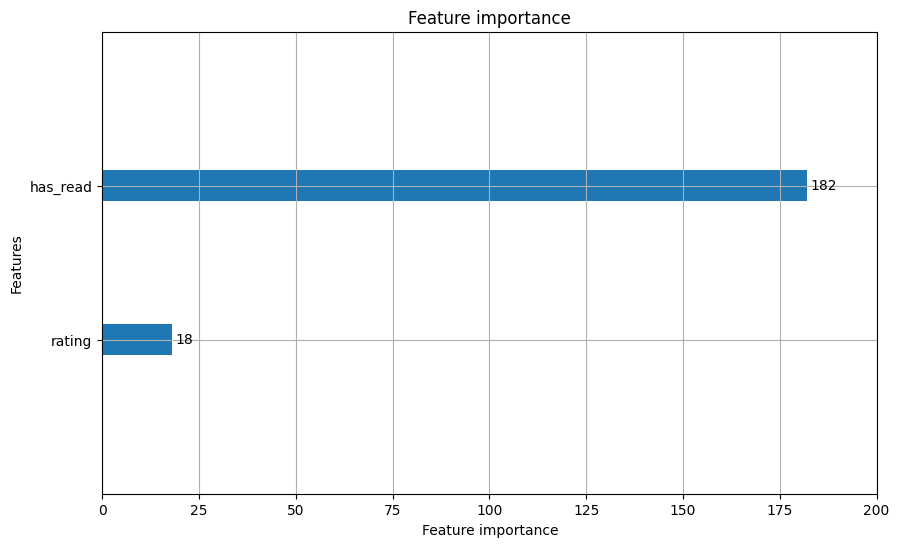

In [41]:
# --- EVALUATE & SAVE ---
val_preds = model.predict(X_val)
acc = accuracy_score(y_val, val_preds)
print(f"Validation Accuracy: {acc:.4f}")

# Save
model.booster_.save_model(str(config.MODEL_DIR / config.MODEL_FILENAME))
with open(config.MODEL_DIR / "features_list.json", "w") as f:
    json.dump(features, f)

lgb.plot_importance(model, max_num_features=20, figsize=(10, 6))


In [48]:
# --- PREPARE CANDIDATE FEATURES ---
candidates_with_meta = candidates_df.copy()

import ast

def fix_list_column(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        try:
            # Формат "1,2,3"
            if "," in x and not x.startswith("["):
                return [int(v) for v in x.split(",")]
            # Формат "[1,2,3]"
            return list(map(int, ast.literal_eval(x)))
        except:
            return []
    return []

# FIX: convert book_id_list to real list
if "book_id_list" in candidates_with_meta.columns:
    candidates_with_meta["book_id_list"] = candidates_with_meta["book_id_list"].apply(fix_list_column)
    candidates_with_meta = candidates_with_meta.explode("book_id_list")
    candidates_with_meta = candidates_with_meta.rename(columns={"book_id_list": constants.COL_BOOK_ID})

if constants.COL_BOOK_ID not in candidates_with_meta.columns:
    raise KeyError("book_id not found even after explode")

# Safely cast to int
candidates_with_meta[constants.COL_BOOK_ID] = pd.to_numeric(
    candidates_with_meta[constants.COL_BOOK_ID], errors="coerce"
).astype("Int64")

# Build book features
book_features = featured_df[[constants.COL_BOOK_ID]].drop_duplicates()
feature_cols = [
    col for col in featured_df.columns
    if col not in [
        constants.COL_USER_ID, constants.COL_BOOK_ID, constants.COL_SOURCE,
        constants.COL_TIMESTAMP, constants.COL_HAS_READ, constants.COL_TARGET, constants.COL_PREDICTION
    ] + config.CAT_FEATURES
    and not col.startswith("tfidf_") and not col.startswith("bert_")
]
text_feature_cols = [col for col in featured_df.columns if col.startswith("tfidf_") or col.startswith("bert_")]
cols_to_extract = [constants.COL_BOOK_ID] + feature_cols + text_feature_cols

book_features_df = featured_df[cols_to_extract].drop_duplicates(subset=[constants.COL_BOOK_ID])

book_features_df[constants.COL_BOOK_ID] = pd.to_numeric(
    book_features_df[constants.COL_BOOK_ID], errors="coerce"
).astype("Int64")

# Drop duplicates before merge
cols_to_drop = [
    c for c in book_features_df.columns
    if c in candidates_with_meta.columns and c != constants.COL_BOOK_ID
]
candidates_with_meta = candidates_with_meta.drop(columns=cols_to_drop)

# Merge OK now
candidates_with_meta = candidates_with_meta.merge(book_features_df, on=constants.COL_BOOK_ID, how="left")


In [52]:
# --- RESTORE ALL MISSING FEATURES (user/book) BEFORE AGGREGATES ---

needed_columns = set(featured_df.columns)

missing_cols = [c for c in needed_columns if c not in candidates_with_meta.columns]

print("Restoring missing columns:", missing_cols)

for col in missing_cols:
    if col == constants.COL_BOOK_ID:
        continue

    # если это книжная фича → мержим по book_id
    if col in featured_df.columns:
        if col not in [constants.COL_USER_ID, constants.COL_TARGET, constants.COL_HAS_READ]:
            # book-level feature
            mapping = featured_df[[constants.COL_BOOK_ID, col]].drop_duplicates(
                subset=[constants.COL_BOOK_ID]
            )
            candidates_with_meta = candidates_with_meta.merge(
                mapping, on=constants.COL_BOOK_ID, how="left"
            )
        else:
            # user-level features → просто ставим NaN, их заполнит handle_missing_values()
            candidates_with_meta[col] = np.nan


Restoring missing columns: ['timestamp', 'language', 'source', 'gender', 'publisher', 'age', 'has_read', 'publication_year']


In [53]:
# Aggregates
print("Computing aggregates on FULL train data...")
candidates_with_agg = add_aggregate_features(candidates_with_meta.copy(), train_df)

print("Handling missing...")
candidates_final = handle_missing_values(candidates_with_agg, train_df)

# Load feature list
with open(config.MODEL_DIR / "features_list.json", "r") as f:
    features = json.load(f)

# Ensure all columns exist
for feat in features:
    if feat not in candidates_final.columns:
        candidates_final[feat] = 0

# Match categories
for col in features:
    if col in featured_df.columns and featured_df[col].dtype.name == "category":
        train_cats = featured_df[col].cat.categories
        candidates_final[col] = candidates_final[col].astype(str)
        # Fill unknown categories
        valid_mask = candidates_final[col].isin([str(c) for c in train_cats])
        if not valid_mask.all():
            candidates_final.loc[~valid_mask, col] = str(train_cats[0])
        candidates_final[col] = pd.Categorical(candidates_final[col], categories=train_cats, ordered=False)

X_test = candidates_final[features]


Computing aggregates on FULL train data...
Adding aggregate features...
Handling missing...
Handling missing values...


In [60]:
print("Forcing categorical feature alignment...")

# 1. Восстанавливаем список категориальных колонок, который был в тренинге
# он был передан LGBMClassifier в параметре categorical_feature
train_cats = config.CAT_FEATURES.copy()

# 2. Убедимся, что тест содержит ВСЕ эти колонки
for col in train_cats:
    if col not in X_test.columns:
        X_test[col] = "unknown"

# 3. Меняем dtype — ТОЛЬКО эти колонки должны быть category
for col in X_test.columns:
    if col in train_cats:
        # train categories:
        cats = featured_df[col].astype("category").cat.categories if col in featured_df.columns else []
        X_test[col] = X_test[col].astype(str)
        if len(cats) > 0:
            # заменяем неизвестные
            allowed = [str(c) for c in cats]
            mask = X_test[col].isin(allowed)
            if not mask.all():
                X_test.loc[~mask, col] = allowed[0]
            X_test[col] = pd.Categorical(X_test[col], categories=cats)
        else:
            # fallback: просто строковые категории без фиксированного списка
            X_test[col] = X_test[col].astype("category")
    else:
        # все остальные НЕ категориальные!
        if str(X_test[col].dtype) == "category":
            X_test[col] = X_test[col].astype(str)


Forcing categorical feature alignment...


In [62]:
TEXT_COLS = ["title", "author_name"]

for col in TEXT_COLS:
    if col in X_test.columns:
        print(f"Dropping raw text column for inference: {col}")
        X_test = X_test.drop(columns=[col])


Dropping raw text column for inference: title
Dropping raw text column for inference: author_name


In [63]:
# --- PREDICT & RANK ---
print("Predicting...")
model = lgb.Booster(model_file=str(config.MODEL_DIR / config.MODEL_FILENAME))
probs = model.predict(X_test) # (N, 3)

# Handle potential 1D output just in case, though multiclass usually gives 2D
probs = np.array(probs)
if probs.ndim == 1:
    probs = probs.reshape(-1, 3)

# Ranking score: p1*1 + p2*2
ranking_score = probs[:, 1] * 1.0 + probs[:, 2] * 2.5  # Boost class 2
candidates_final["prediction"] = ranking_score

print("Ranking and generating submission...")
submission_rows = []
for user_id in tqdm(targets_df[constants.COL_USER_ID]):
    user_preds = candidates_final[candidates_final[constants.COL_USER_ID] == user_id]
    if len(user_preds) == 0:
        book_list = ""
    else:
        top_k = user_preds.sort_values("prediction", ascending=False).head(constants.MAX_RANKING_LENGTH)
        book_list = ",".join(top_k[constants.COL_BOOK_ID].astype(str).tolist())

    submission_rows.append({constants.COL_USER_ID: user_id, constants.COL_BOOK_ID_LIST: book_list})

submission_df = pd.DataFrame(submission_rows)
submission_path = config.SUBMISSION_DIR / constants.SUBMISSION_FILENAME
submission_df.to_csv(submission_path, index=False)
print(f"Submission saved to {submission_path}")


Predicting...
Ranking and generating submission...


100%|██████████| 3512/3512 [01:43<00:00, 33.91it/s]


Submission saved to output/submissions/submission.csv


## 9. Проверка решения (Submission Validation)

In [64]:
def validate_submission_format(df: pd.DataFrame) -> None:
    # 1. Check columns
    required_cols = {"user_id", "book_id_list"}
    if not required_cols.issubset(df.columns):
        missing = required_cols - set(df.columns)
        raise ValueError(f"Missing required columns: {missing}")

    # 2. Check user_id
    if df["user_id"].isna().any():
        raise ValueError("Column 'user_id' contains null values")

    duplicates = df.duplicated(subset=["user_id"])
    if duplicates.any():
        raise ValueError(f"Found {duplicates.sum()} duplicate user_id values")

    # 3. Check book_id_list format
    max_books = 20
    invalid_rows = []

    for idx, row in df.iterrows():
        book_list_str = row["book_id_list"]
        if pd.isna(book_list_str) or book_list_str == "":
            continue

        try:
            book_ids = [int(x.strip()) for x in str(book_list_str).split(",") if x.strip()]
        except ValueError as e:
            invalid_rows.append((idx, f"Invalid format: {e}"))
            continue

        if len(book_ids) != len(set(book_ids)):
            invalid_rows.append((idx, "Duplicate book_ids"))

        if len(book_ids) > max_books:
            invalid_rows.append((idx, f"Too many books ({len(book_ids)})"))

    if invalid_rows:
        raise ValueError(f"Found {len(invalid_rows)} invalid entries. Example: {invalid_rows[0]}")

    print("✅ Validation successful!")

print("Validating submission file...")
try:
    submission_df = pd.read_csv(config.SUBMISSION_DIR / constants.SUBMISSION_FILENAME)
    validate_submission_format(submission_df)
except Exception as e:
    print(f"❌ Validation failed: {e}")


Validating submission file...
✅ Validation successful!
